In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools
import matplotlib.dates as mdates
import pandas as pd

I0000 00:00:1788783723.271781  393812 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os

# Data path from AGENTS.md
data_folder = "/home/haseebumer/content/data/extracted/"

# !change model name for different models!
model_name = "LSTM_nowcast_2017_2019_data"
output_folder = os.path.join("model_output", model_name)

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# File paths for extracted datasets
trainval_images_path = os.path.join(data_folder, "trainval_images_log.npy")
trainval_pv_path = os.path.join(data_folder, "trainval_pv_log.npy")
test_images_path = os.path.join(data_folder, "test_images_log.npy")
test_pv_path = os.path.join(data_folder, "test_pv_log.npy")

times_trainval_path = os.path.join(data_folder, "times_trainval.npy")
times_test_path = os.path.join(data_folder, "times_test.npy")

print("data_folder:", data_folder)
print("output_folder:", output_folder)
print("trainval_images:", trainval_images_path)
print("trainval_pv:", trainval_pv_path)

data_folder: /home/haseebumer/content/data/extracted/
output_folder: model_output/LSTM_nowcast_2017_2019_data
trainval_images: /home/haseebumer/content/data/extracted/trainval_images_log.npy
trainval_pv: /home/haseebumer/content/data/extracted/trainval_pv_log.npy


## Data Loading & Training


In [3]:
# Model & Training parameters
SEQ_LEN = 16  # Number of historical time steps (lags) used as input sequence
# 0 for nowcast (predicting t from t-SEQ_LEN...t-1), or >0 for future horizon
FORECAST_HORIZON = 0
NUM_FOLDS = 10  # 10-fold cross validation
NUM_EPOCHS = 200  # Max epochs (EarlyStopping will halt earlier)
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 10  # Early stopping patience

In [4]:
trainval_pv = np.load(trainval_pv_path).astype(np.float32)
test_pv = np.load(test_pv_path).astype(np.float32)

times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)

print(f"trainval_pv shape: {trainval_pv.shape} | times: {times_trainval.shape}")
print(f"test_pv shape:         {test_pv.shape} | times: {times_test.shape}")

trainval_pv shape: (349372,) | times: (349372,)
test_pv shape:         (14003,) | times: (14003,)


In [5]:
def create_day_aware_sequences(pv_array, times_array, seq_len=16, horizon=0):
    """
    Constructs (X, y, sequence_dates, sequence_times) sequences
    ensuring that no sequence crosses overnight boundaries or
    distinct dates.
    """

    dates = np.array(
        [
            (
                t.date()
                if isinstance(t, (datetime.datetime, datetime.date))
                else pd.to_datetime(t).date()
            )
            for t in times_array
        ]
    )

    unique_dates = np.unique(dates)

    X_list, y_list = [], []
    valid_dates_list = []
    valid_times_list = []

    for d in unique_dates:
        day_indices = np.where(dates == d)[0]
        num_day_points = len(day_indices)

        # Minimum required points for sequence + target
        if num_day_points <= seq_len + horizon:
            continue

        day_pv = pv_array[day_indices]
        day_times = times_array[day_indices]

        for i in range(seq_len, num_day_points - horizon):
            seq_x = day_pv[i - seq_len : i]

            target_idx = i + horizon
            seq_y = day_pv[target_idx]

            X_list.append(seq_x)
            y_list.append(seq_y)
            valid_dates_list.append(d)
            valid_times_list.append(day_times[target_idx])

    X = np.expand_dims(
        np.array(X_list, dtype=np.float32), axis=-1
    )  # Shape: (N, seq_len, 1)

    y = np.array(y_list, dtype=np.float32)  # Shape: (N,)

    valid_dates = np.array(valid_dates_list)
    valid_times = np.array(valid_times_list)

    return X, y, valid_dates, valid_times


X_trainval, y_trainval, dates_trainval_seq, times_trainval_seq = (
    create_day_aware_sequences(
        trainval_pv, times_trainval, seq_len=SEQ_LEN, horizon=FORECAST_HORIZON
    )
)

X_test, y_test, dates_test_seq, times_test_seq = create_day_aware_sequences(
    test_pv, times_test, seq_len=SEQ_LEN, horizon=FORECAST_HORIZON
)

print(f"X_trainval shape: {X_trainval.shape}, " f"y_trainval shape: {y_trainval.shape}")
print(f"X_test shape: {X_test.shape}, " f"y_test shape: {y_test.shape}")

X_trainval shape: (341420, 16, 1), y_trainval shape: (341420,)
X_test shape: (13683, 16, 1), y_test shape: (13683,)


In [6]:
def shuffle_unique_dates(dates_array, seed=1):
    """
    Shuffles the unique CALENDAR DATES (not sample indices).
    Fold boundaries are cut on this array, so folds are day-based.
    """
    unique_dates = np.unique(dates_array)
    rng = np.random.RandomState(seed)
    rng.shuffle(unique_dates)
    return unique_dates


def cv_split_indices(dates_array_full, shuffled_unique_dates, fold_index, num_folds=10):
    """
    Splits by whole days: the fold_index-th slice of shuffled_unique_dates
    becomes the validation dates. Every sample whose date falls in that
    slice goes to validation; everything else goes to training.
    No calendar day is ever split across train and validation.
    """
    num_days = len(shuffled_unique_dates)
    val_start = int(fold_index / num_folds * num_days)
    val_end = int((fold_index + 1) / num_folds * num_days)

    val_dates = set(shuffled_unique_dates[val_start:val_end])

    val_mask = np.isin(dates_array_full, list(val_dates))
    train_mask = ~val_mask

    all_indices = np.arange(len(dates_array_full))
    train_idx = all_indices[train_mask]
    val_idx = all_indices[val_mask]

    rng = np.random.RandomState(fold_index)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def build_tf_dataset(X, y, indices, batch_size=256, is_training=True):
    """
    Builds an optimized tf.data.Dataset pipeline.
    """
    X_sub = X[indices]
    y_sub = y[indices]

    ds = tf.data.Dataset.from_tensor_slices((X_sub, y_sub))

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 10000), seed=42)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds

In [ ]:
def build_lstm_model(
    seq_len=16, num_features=1, lstm_units=(64, 64), dense_units=128, drop_rate=0.2
):
    """
    Builds a 2-layer Stacked LSTM model with Dropout
    and Dense regression output.
    """

    inputs = keras.Input(shape=(seq_len, num_features), name="pv_sequence_input")

    # First LSTM layer
    x = keras.layers.LSTM(lstm_units[0], return_sequences=True, name="lstm_1")(inputs)

    x = keras.layers.Dropout(drop_rate, name="drop_1")(x)

    # Second LSTM layer
    x = keras.layers.LSTM(lstm_units[1], return_sequences=False, name="lstm_2")(x)

    x = keras.layers.Dropout(drop_rate, name="drop_2")(x)

    # Fully-connected projection head
    x = keras.layers.Dense(dense_units, activation="relu", name="dense_1")(x)

    x = keras.layers.Dropout(drop_rate, name="drop_3")(x)

    outputs = keras.layers.Dense(units=1, activation="linear", name="pv_prediction")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="LSTM_Solar_Forecast")

    return model


sample_model = build_lstm_model(seq_len=SEQ_LEN, num_features=1)

sample_model.summary()

I0000 00:00:1788783728.343790  393812 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8101 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:23:00.0, compute capability: 8.6
I0000 00:00:1788783728.345054  393812 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 7508 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2d:00.0, compute capability: 8.6


Model: "LSTM_Solar_Forecast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pv_sequence_input (InputLayer)  │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pv_prediction (Dense)           │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
shuffled_unique_dates = shuffle_unique_dates(dates_trainval_seq, seed=1)

# --- Resume support: load existing history if this cell was run before ---
history_paths = {
    "train_loss": os.path.join(output_folder, "train_loss_hist.npy"),
    "val_loss": os.path.join(output_folder, "val_loss_hist.npy"),
    "train_mae": os.path.join(output_folder, "train_mae_hist.npy"),
    "val_mae": os.path.join(output_folder, "val_mae_hist.npy"),
}

if all(os.path.exists(p) for p in history_paths.values()):
    train_loss_hist = list(np.load(history_paths["train_loss"], allow_pickle=True))
    val_loss_hist = list(np.load(history_paths["val_loss"], allow_pickle=True))
    train_mae_hist = list(np.load(history_paths["train_mae"], allow_pickle=True))
    val_mae_hist = list(np.load(history_paths["val_mae"], allow_pickle=True))
    print(
        f"Resuming: found existing history for {len(train_loss_hist)} completed fold(s)."
    )
else:
    train_loss_hist = []
    val_loss_hist = []
    train_mae_hist = []
    val_mae_hist = []

# A fold counts as "done" only if BOTH its checkpoint exists AND its history was
# already recorded above (checkpoint alone isn't proof the fold finished/saved).
start_fold = len(train_loss_hist)

if start_fold >= NUM_FOLDS:
    print(f"All {NUM_FOLDS} folds already completed. Nothing to train.")

for fold in range(start_fold, NUM_FOLDS):

    print(f" Repetition / Fold {fold + 1} of {NUM_FOLDS} ")

    keras.backend.clear_session()

    model = build_lstm_model(seq_len=SEQ_LEN, num_features=1)

    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    save_directory = os.path.join(output_folder, f"repetition_{fold + 1}")

    os.makedirs(save_directory, exist_ok=True)

    checkpoint_path = os.path.join(
        save_directory, f"best_model_repetition_{fold + 1}.h5"
    )

    # Splits & Datasets (day-level split — no day appears in both train and val)
    idx_train, idx_val = cv_split_indices(
        dates_trainval_seq, shuffled_unique_dates, fold, NUM_FOLDS
    )

    ds_train = build_tf_dataset(
        X_trainval, y_trainval, idx_train, batch_size=BATCH_SIZE, is_training=True
    )

    ds_val = build_tf_dataset(
        X_trainval, y_trainval, idx_val, batch_size=BATCH_SIZE, is_training=False
    )

    # Callbacks
    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    # Training
    history = model.fit(
        ds_train,
        epochs=NUM_EPOCHS,
        validation_data=ds_val,
        callbacks=[earlystop, checkpoint, reduce_lr],
        verbose=1,
    )

    # Store training history
    train_loss_hist.append(history.history["loss"])

    val_loss_hist.append(history.history["val_loss"])

    train_mae_hist.append(history.history["mae"])

    val_mae_hist.append(history.history["val_mae"])

    # Save history arrays (checkpointed after EVERY fold, so a crash mid-run
    # only loses the in-progress fold, not previously completed ones)
    np.save(
        os.path.join(output_folder, "train_loss_hist.npy"),
        np.array(train_loss_hist, dtype=object),
    )

    np.save(
        os.path.join(output_folder, "val_loss_hist.npy"),
        np.array(val_loss_hist, dtype=object),
    )

    np.save(
        os.path.join(output_folder, "train_mae_hist.npy"),
        np.array(train_mae_hist, dtype=object),
    )

    np.save(
        os.path.join(output_folder, "val_mae_hist.npy"),
        np.array(val_mae_hist, dtype=object),
    )

    print(f"Fold {fold + 1} complete and saved.")

Resuming: found existing history for 10 completed fold(s).
All 10 folds already completed. Nothing to train.


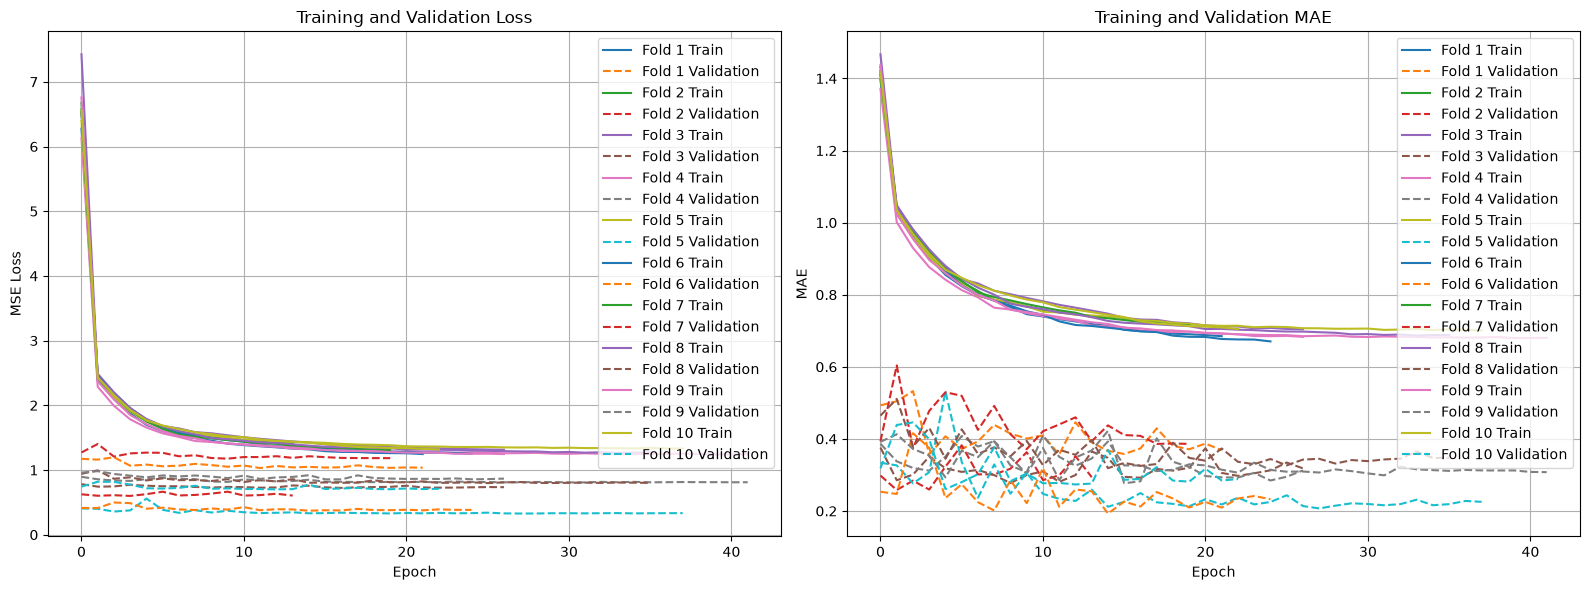

In [9]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))


# TRAINING & VALIDATION LOSS

for fold in range(NUM_FOLDS):
    axarr[0].plot(train_loss_hist[fold], label=f"Fold {fold + 1} Train")

    axarr[0].plot(
        val_loss_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[0].set_xlabel("Epoch")
axarr[0].set_ylabel("MSE Loss")
axarr[0].set_title("Training and Validation Loss")
axarr[0].legend()
axarr[0].grid(True)


# TRAINING & VALIDATION MAE

for fold in range(NUM_FOLDS):
    axarr[1].plot(train_mae_hist[fold], label=f"Fold {fold + 1} Train")

    axarr[1].plot(
        val_mae_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[1].set_xlabel("Epoch")
axarr[1].set_ylabel("MAE")
axarr[1].set_title("Training and Validation MAE")
axarr[1].legend()
axarr[1].grid(True)


plt.tight_layout()
plt.show()

In [10]:
best_train_loss_mse = np.zeros(NUM_FOLDS)
best_val_loss_mse = np.zeros(NUM_FOLDS)

for i in range(NUM_FOLDS):
    best_val_loss_mse[i] = np.min(val_loss_hist[i])

    idx = np.argmin(val_loss_hist[i])
    best_train_loss_mse[i] = train_loss_hist[i][idx]

    print(
        f"Model {i + 1:02d} | "
        f"Train RMSE: {np.sqrt(best_train_loss_mse[i]):.3f} kW | "
        f"Val RMSE: {np.sqrt(best_val_loss_mse[i]):.3f} kW"
    )

print(f"Mean Train RMSE: " f"{np.mean(np.sqrt(best_train_loss_mse)):.3f} kW")
print(f"Mean Validation RMSE: " f"{np.mean(np.sqrt(best_val_loss_mse)):.3f} kW")

Model 01 | Train RMSE: 1.169 kW | Val RMSE: 1.015 kW
Model 02 | Train RMSE: 1.390 kW | Val RMSE: 0.774 kW
Model 03 | Train RMSE: 1.176 kW | Val RMSE: 0.851 kW
Model 04 | Train RMSE: 1.122 kW | Val RMSE: 0.899 kW
Model 05 | Train RMSE: 1.161 kW | Val RMSE: 0.572 kW
Model 06 | Train RMSE: 1.163 kW | Val RMSE: 0.609 kW
Model 07 | Train RMSE: 1.210 kW | Val RMSE: 1.084 kW
Model 08 | Train RMSE: 1.138 kW | Val RMSE: 0.893 kW
Model 09 | Train RMSE: 1.142 kW | Val RMSE: 0.925 kW
Model 10 | Train RMSE: 1.205 kW | Val RMSE: 0.837 kW
Mean Train RMSE: 1.188 kW
Mean Validation RMSE: 0.846 kW


In [11]:
predictions = np.zeros((NUM_FOLDS, len(X_test)), dtype=np.float32)

for fold in range(NUM_FOLDS):
    checkpoint_path = os.path.join(
        output_folder, f"repetition_{fold + 1}", f"best_model_repetition_{fold + 1}.h5"
    )

    print(f"Loading fold {fold + 1} model from: " f"{checkpoint_path}")

    fold_model = keras.models.load_model(checkpoint_path, compile=False)

    pred = fold_model.predict(X_test, batch_size=512, verbose=0)

    predictions[fold] = np.squeeze(pred)

# Save individual fold predictions
np.save(os.path.join(output_folder, "test_predictions_all_folds.npy"), predictions)

# Ensemble average
ensemble_predictions = np.mean(predictions, axis=0)

np.save(
    os.path.join(output_folder, "test_predictions_ensemble.npy"), ensemble_predictions
)

Loading fold 1 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_1/best_model_repetition_1.h5


I0000 00:00:1788783729.938365  393973 cuda_dnn.cc:461] Loaded cuDNN version 92400


Loading fold 2 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_2/best_model_repetition_2.h5
Loading fold 3 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_3/best_model_repetition_3.h5
Loading fold 4 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_4/best_model_repetition_4.h5
Loading fold 5 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_5/best_model_repetition_5.h5
Loading fold 6 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_6/best_model_repetition_6.h5
Loading fold 7 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_7/best_model_repetition_7.h5
Loading fold 8 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_8/best_model_repetition_8.h5
Loading fold 9 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_9/best_model_repetition_9.h5
Loading fold 10 model from: model_output/LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5


COMPLETE TEST SET NOWCAST RESULTS
Total Test Sequences: 13,683
Overall Test RMSE:    1.383 kW
Overall Test MAE:     0.505 kW


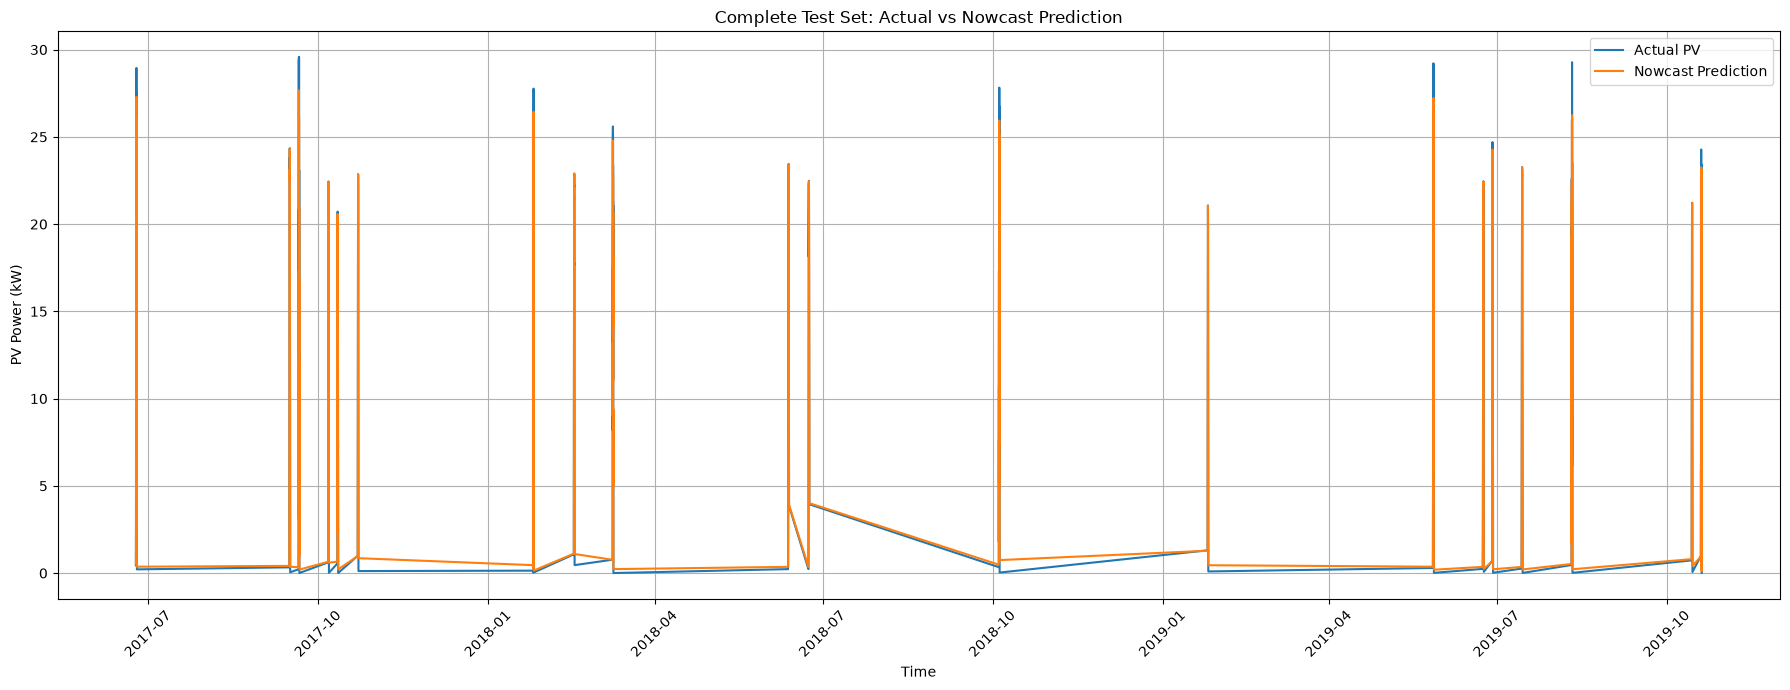

In [12]:
# TEST SET EVALUATION

# Calculate prediction errors
errors = ensemble_predictions - y_test

# RMSE
rmse_overall = np.sqrt(np.mean(np.square(errors)))

# MAE
mae_overall = np.mean(np.abs(errors))

print("COMPLETE TEST SET NOWCAST RESULTS")

print(f"Total Test Sequences: {len(y_test):,}")
print(f"Overall Test RMSE:    {rmse_overall:.3f} kW")
print(f"Overall Test MAE:     {mae_overall:.3f} kW")


# TIME-SERIES PLOT

plt.figure(figsize=(18, 7))

plt.plot(times_test_seq, y_test, label="Actual PV")

plt.plot(times_test_seq, ensemble_predictions, label="Nowcast Prediction")

plt.xlabel("Time")
plt.ylabel("PV Power (kW)")
plt.title("Complete Test Set: Actual vs Nowcast Prediction")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# SUNNY AND CLOUD DATES FROM THE SKIPP'D PAPER

sunny_dates = [
    (2017, 9, 15),
    (2017, 10, 6),
    (2017, 10, 22),
    (2018, 2, 16),
    (2018, 6, 12),
    (2018, 6, 23),
    (2019, 1, 25),
    (2019, 6, 23),
    (2019, 7, 14),
    (2019, 10, 14),
]

cloudy_dates = [
    (2017, 6, 24),
    (2017, 9, 20),
    (2017, 10, 11),
    (2018, 1, 25),
    (2018, 3, 9),
    (2018, 10, 4),
    (2019, 5, 27),
    (2019, 6, 28),
    (2019, 8, 10),
    (2019, 10, 19),
]

sunny_dates_test = [datetime.date(y, m, d) for y, m, d in sunny_dates]

cloudy_dates_test = [datetime.date(y, m, d) for y, m, d in cloudy_dates]

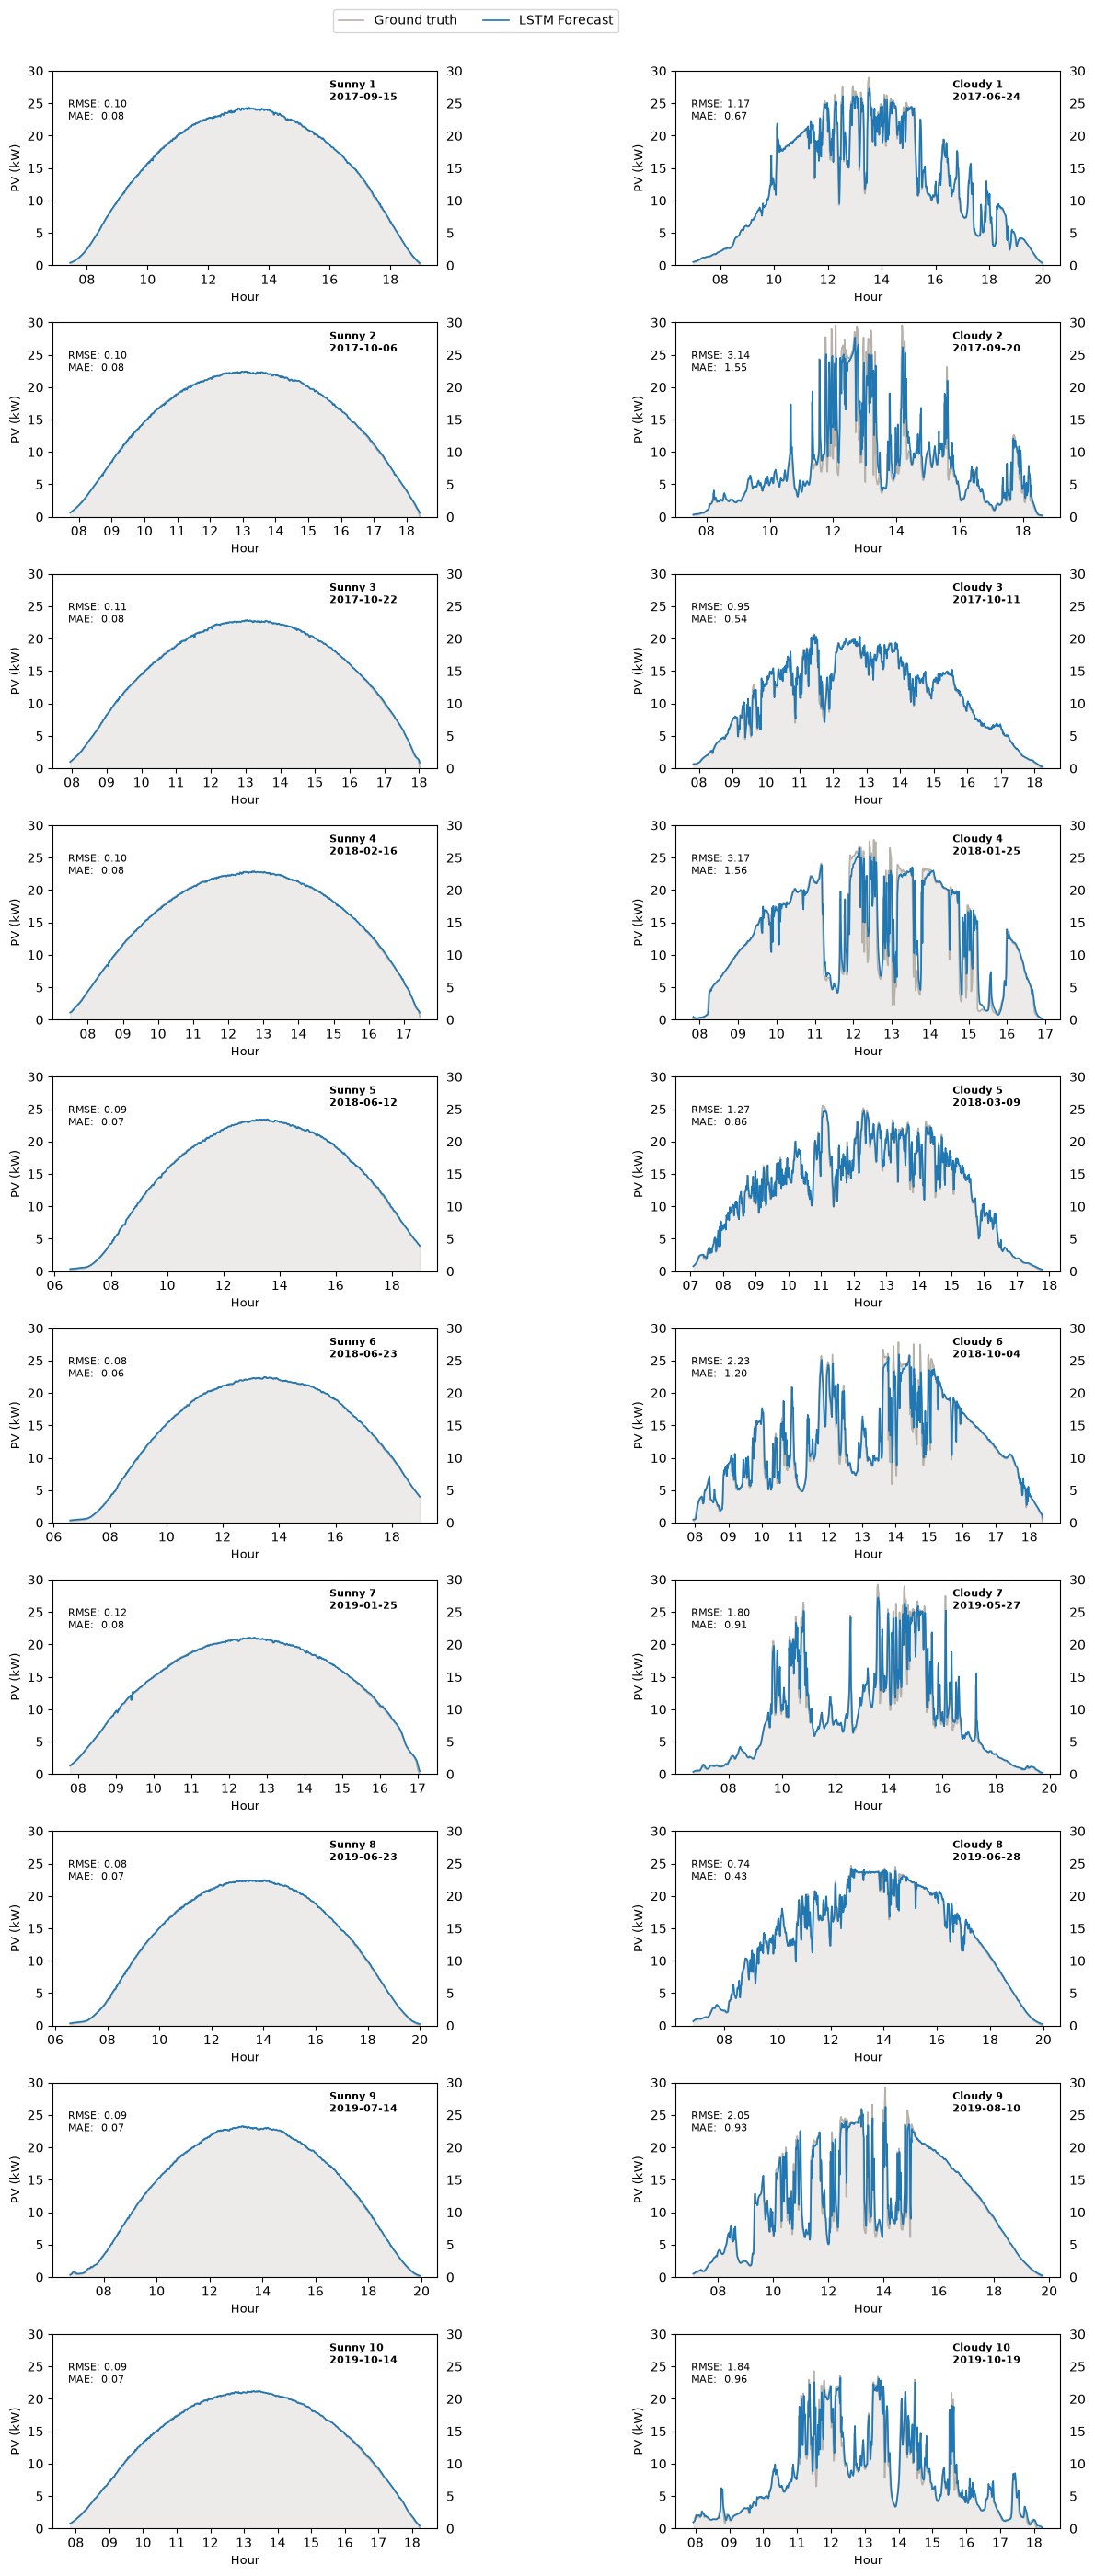

In [16]:
hours_test_seq = np.array(
    [
        (
            t.time()
            if isinstance(t, (datetime.datetime, datetime.time))
            else pd.to_datetime(t).time()
        )
        for t in times_test_seq
    ]
)

fig, axarr = plt.subplots(10, 2, sharex=False, sharey=True, figsize=(12, 28))

xfmt = mdates.DateFormatter("%H")
fmt_date = datetime.date(2000, 1, 1)

COLOR_GT = "#B6B1A9"
COLOR_PRED = "#1f77b4"


# Plot Sunny Days
for i, date in enumerate(sunny_dates_test):
    ax = axarr[i, 0]
    date_mask = dates_test_seq == date

    hours_xaxis = [
        datetime.datetime.combine(fmt_date, h) for h in hours_test_seq[date_mask]
    ]

    y_true_d = y_test[date_mask]
    y_pred_d = ensemble_predictions[date_mask]

    d_rmse = np.sqrt(np.mean(np.square(y_true_d - y_pred_d)))
    d_mae = np.mean(np.abs(y_true_d - y_pred_d))

    ax.plot(
        hours_xaxis,
        y_true_d,
        color=COLOR_GT,
        linewidth=1.2,
        label="Ground truth" if i == 0 else "",
    )

    ax.fill_between(hours_xaxis, 0, y_true_d, color=COLOR_GT, alpha=0.25)

    ax.plot(
        hours_xaxis,
        y_pred_d,
        color=COLOR_PRED,
        linewidth=1.2,
        label="LSTM Forecast" if i == 0 else "",
    )

    ax.set_xlabel("Hour", fontsize=9)
    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)

    # Show PV values on the right side too
    ax.tick_params(axis="y", labelleft=True, labelright=True)

    ax.text(
        0.72,
        0.85,
        f"Sunny {i + 1}\n{date}",
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
    )

    ax.text(
        0.04,
        0.75,
        f"RMSE: {d_rmse:.2f}\nMAE:  {d_mae:.2f}",
        transform=ax.transAxes,
        fontsize=8,
    )


# Plot Cloudy Days
for i, date in enumerate(cloudy_dates_test):
    ax = axarr[i, 1]
    date_mask = dates_test_seq == date

    hours_xaxis = [
        datetime.datetime.combine(fmt_date, h) for h in hours_test_seq[date_mask]
    ]

    y_true_d = y_test[date_mask]
    y_pred_d = ensemble_predictions[date_mask]

    d_rmse = np.sqrt(np.mean(np.square(y_true_d - y_pred_d)))
    d_mae = np.mean(np.abs(y_true_d - y_pred_d))

    ax.plot(hours_xaxis, y_true_d, color=COLOR_GT, linewidth=1.2)

    ax.fill_between(hours_xaxis, 0, y_true_d, color=COLOR_GT, alpha=0.25)

    ax.plot(hours_xaxis, y_pred_d, color=COLOR_PRED, linewidth=1.2)

    ax.set_xlabel("Hour", fontsize=9)
    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)

    # Show PV values on the right side too
    ax.tick_params(axis="y", labelleft=True, labelright=True)

    ax.text(
        0.72,
        0.85,
        f"Cloudy {i + 1}\n{date}",
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
    )

    ax.text(
        0.04,
        0.75,
        f"RMSE: {d_rmse:.2f}\nMAE:  {d_mae:.2f}",
        transform=ax.transAxes,
        fontsize=8,
    )


axarr[0, 0].set_ylim(0, 30)

axarr[0, 0].legend(bbox_to_anchor=[1.1, 1.35], loc="upper center", ncol=2, frameon=True)


plt.tight_layout()

plt.show()